# Import pandas and load the dataset

In [1]:
import pandas as pd

# Load the training dataset
df = pd.read_csv("train.csv")

# Show the first 5 rows
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [2]:
# Check the number of rows and columns
df.shape

(159571, 8)

In [3]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [4]:
# Check for duplicate rows
df.duplicated().sum()

0

In [5]:
# Check the number of Toxic and Non-Toxic comments
df["toxic"].value_counts()

toxic
0    144277
1     15294
Name: count, dtype: int64

In [6]:
# Check the percentage of each class
df["toxic"].value_counts(normalize=True) * 100

toxic
0    90.415552
1     9.584448
Name: proportion, dtype: float64

In [7]:
# Step 7: Analyze the length of comments

# Create a new column to measure the number of characters in each comment
df["text_length"] = df["comment_text"].str.len()

# View statistics about comment length
df["text_length"].describe()

count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: text_length, dtype: float64

In [8]:
# Compare comment length between Toxic and Non-Toxic comments
df.groupby("toxic")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
toxic,,,,,,,,
0,144277.0,404.549339,586.850889,6.0,102.0,216.0,453.0,5000.0
1,15294.0,295.246044,617.379025,8.0,59.0,123.0,271.0,5000.0


This suggests that comment length may contain useful information for the model, although it will not be enough by itself to detect toxicity.

In [9]:
from collections import Counter
import re

# Combine all comments into one large text
all_text = " ".join(df["comment_text"].astype(str))

# Extract words
words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

# Count how often each word appears
word_counts = Counter(words)

# Show the 20 most common words
word_counts.most_common(20)

[('the', 496796),
 ('to', 297408),
 ('i', 240405),
 ('of', 224547),
 ('and', 224092),
 ('you', 218308),
 ('a', 215943),
 ('is', 176405),
 ('that', 160867),
 ('it', 148644),
 ('in', 145477),
 ('for', 102723),
 ('this', 97655),
 ('not', 93774),
 ('on', 89968),
 ('be', 83474),
 ('as', 77444),
 ('s', 72566),
 ('have', 72244),
 ('are', 72041)]

In [10]:
# Check for missing comments
df["comment_text"].isnull().sum()

0

In [11]:
# Check for empty or whitespace-only comments
(df["comment_text"].str.strip() == "").sum()

0

In [12]:
# Check how many comments belong to each toxicity category
df[["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [13]:
# Check other toxicity labels among Toxic comments
df[df["toxic"] == 1][
    ["severe_toxic", "obscene", "threat", "insult", "identity_hate"]
].sum()

severe_toxic     1595
obscene          7926
threat            449
insult           7344
identity_hate    1302
dtype: int64

Give me only the comments that are labelled Toxic.

In [14]:
df[df["toxic"] == 1][
    ["severe_toxic", "obscene", "threat", "insult", "identity_hate"]
].sum()

severe_toxic     1595
obscene          7926
threat            449
insult           7344
identity_hate    1302
dtype: int64

The dataset contains six toxicity-related labels, but for this project I use the toxic label as the main binary target, while the other labels are explored to understand the different and overlapping forms of toxic behaviour.

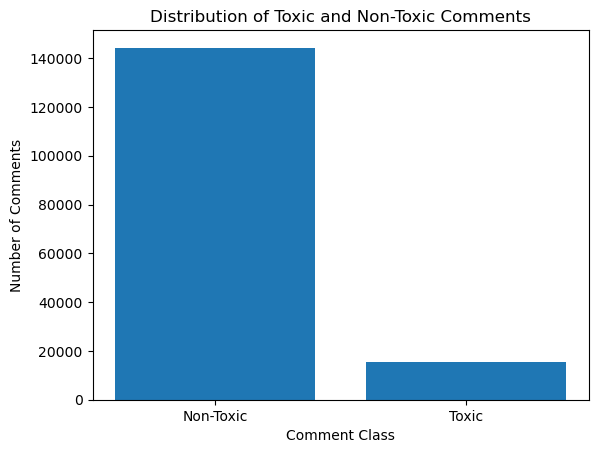

In [15]:
import matplotlib.pyplot as plt

# Count each target class
class_counts = df["toxic"].value_counts()

# Create a bar chart
plt.bar(["Non-Toxic", "Toxic"], class_counts.values)

# Add chart labels
plt.title("Distribution of Toxic and Non-Toxic Comments")
plt.xlabel("Comment Class")
plt.ylabel("Number of Comments")

# Show the chart
plt.show()

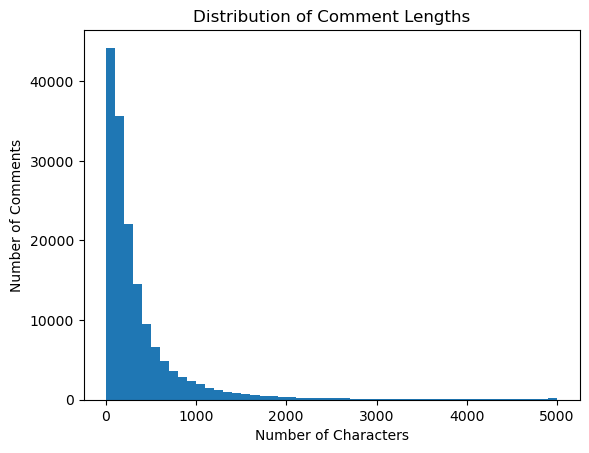

In [16]:
# Plot the distribution of comment lengths
plt.hist(df["text_length"], bins=50)

# Add labels
plt.title("Distribution of Comment Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Comments")

# Show the plot
plt.show()

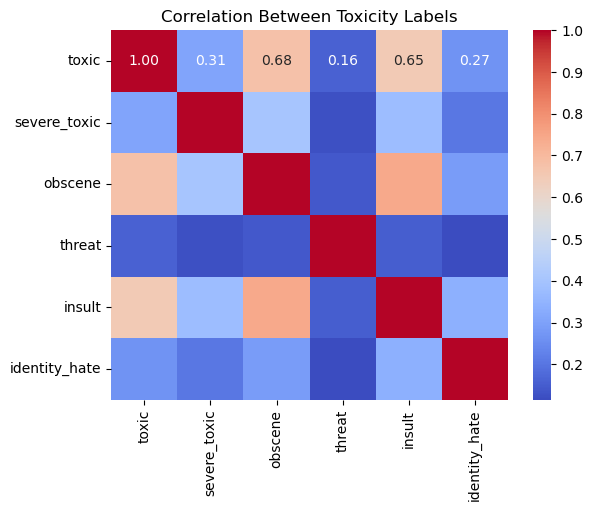

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the toxicity label columns
label_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

# Calculate correlations between the labels
correlation = df[label_columns].corr()

# Create the heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

# Add a title
plt.title("Correlation Between Toxicity Labels")

# Show the heatmap
plt.show()

In [18]:
# Step 15: Separate input text and target

# X contains the comment text
X = df["comment_text"]

# y contains the target: 0 = Non-Toxic, 1 = Toxic
y = df["toxic"]

# Check the first 5 values
X.head(),y.head()

(0    Explanation\nWhy the edits made under my usern...
 1    D'aww! He matches this background colour I'm s...
 2    Hey man, I'm really not trying to edit war. It...
 3    "\nMore\nI can't make any real suggestions on ...
 4    You, sir, are my hero. Any chance you remember...
 Name: comment_text, dtype: object,
 0    0
 1    0
 2    0
 3    0
 4    0
 Name: toxic, dtype: int64)

In [19]:
from sklearn.model_selection import train_test_split

# Split the comments and labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10,
    stratify=y
)

# Check the number of samples in each set
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 127656
Testing samples: 31915


In [20]:
import re

# Function to clean text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [21]:
import re

# Function to clean text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [22]:
# Clean the training and testing comments
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

# Check the cleaned comments
X_train_clean.head()

113417    i will delete personal insults that have nothi...
147217    " do you mean ""which was sufficient""? i'm co...
134052    " this message is regarding the page user:jpgo...
88620     malleus, you said something sometime about bus...
42915     church of st rumbold? i have never known for t...
Name: comment_text, dtype: object

In [23]:
# Show the original comment
print("Original:")
print(X_train.iloc[0])

# Show the cleaned comment
print("\nCleaned:")
print(X_train_clean.iloc[0])

Original:
I will delete personal insults that have nothing to do with the talk discussion. Add them back again and I will go to an admin. Thank you.

Cleaned:
i will delete personal insults that have nothing to do with the talk discussion. add them back again and i will go to an admin. thank you.


# Create Bag of Words features

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# Create the Bag of Words vectorizer
bow = CountVectorizer()

# Learn the vocabulary from the training data
X_train_bow = bow.fit_transform(X_train_clean)

# Use the same vocabulary for the testing data
X_test_bow = bow.transform(X_test_clean)

# Check the shape
print("Training shape:", X_train_bow.shape)
print("Testing shape:", X_test_bow.shape)

Training shape: (127656, 156771)
Testing shape: (31915, 156771)


In [25]:
# Create a BoW vectorizer using unigrams and bigrams
bow_ngram = CountVectorizer(ngram_range=(1, 2))

# Convert training and testing text into features
X_train_bow_ngram = bow_ngram.fit_transform(X_train_clean)
X_test_bow_ngram = bow_ngram.transform(X_test_clean)

# Check the shape
print("Training shape:", X_train_bow_ngram.shape)
print("Testing shape:", X_test_bow_ngram.shape)

Training shape: (127656, 2059094)
Testing shape: (31915, 2059094)


# Create TF-IDF features

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer()

# Convert training text into TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train_clean)

# Convert testing text using the same vocabulary
X_test_tfidf = tfidf.transform(X_test_clean)

# Check the shape
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (127656, 156771)
Testing shape: (31915, 156771)


In [29]:
# Create TF-IDF using unigrams and bigrams
tfidf_ngram = TfidfVectorizer(ngram_range=(1, 2))

# Convert training text into TF-IDF features
X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train_clean)

# Convert testing text using the same vocabulary
X_test_tfidf_ngram = tfidf_ngram.transform(X_test_clean)

# Check the shape
print("Training shape:", X_train_tfidf_ngram.shape)
print("Testing shape:", X_test_tfidf_ngram.shape)

Training shape: (127656, 2059094)
Testing shape: (31915, 2059094)


#  Multinomial Naive Bayes

In [30]:
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
nb = MultinomialNB()

# Train the model
nb.fit(X_train_bow, y_train)

# Predict the test comments
y_pred_nb = nb.predict(X_test_bow)

print("Predictions completed.")

Predictions completed.


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)

# Display the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9471095096349679
Precision: 0.7641618497109827
Recall: 0.6482510624387054
F1-score: 0.7014503006720907


In [ ]:
from sklearn.metrics import confusion_matrix

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

In [ ]:
# Create the Naive Bayes model
nb_tfidf = MultinomialNB()

# Train using TF-IDF features
nb_tfidf.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

print("Predictions completed.")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_nb_tfidf)
precision = precision_score(y_test, y_pred_nb_tfidf)
recall = recall_score(y_test, y_pred_nb_tfidf)
f1 = f1_score(y_test, y_pred_nb_tfidf)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb_tfidf)

print(cm)

In [32]:
# Create TF-IDF using unigrams and bigrams
tfidf_ngram = TfidfVectorizer(ngram_range=(1, 2))

# Convert training text into TF-IDF features
X_train_tfidf_ngram = tfidf_ngram.fit_transform(X_train_clean)

# Convert testing text using the same vocabulary
X_test_tfidf_ngram = tfidf_ngram.transform(X_test_clean)

print("Training shape:", X_train_tfidf_ngram.shape)
print("Testing shape:", X_test_tfidf_ngram.shape)

Training shape: (127656, 2059094)
Testing shape: (31915, 2059094)


In [33]:
# Create the Naive Bayes model
nb_tfidf_ngram = MultinomialNB()

# Train using TF-IDF unigram + bigram features
nb_tfidf_ngram.fit(X_train_tfidf_ngram, y_train)

# Make predictions
y_pred_nb_tfidf_ngram = nb_tfidf_ngram.predict(X_test_tfidf_ngram)

print("Predictions completed.")

Predictions completed.


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_nb_tfidf_ngram)
precision = precision_score(y_test, y_pred_nb_tfidf_ngram)
recall = recall_score(y_test, y_pred_nb_tfidf_ngram)
f1 = f1_score(y_test, y_pred_nb_tfidf_ngram)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9110449631834561
Precision: 1.0
Recall: 0.07191892775416803
F1-score: 0.13418725221103994


# Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logreg_tfidf_ngram = LogisticRegression(max_iter=1000)

# Train using TF-IDF unigram + bigram features
logreg_tfidf_ngram.fit(X_train_tfidf_ngram, y_train)

# Make predictions
y_pred_logreg_tfidf_ngram = logreg_tfidf_ngram.predict(X_test_tfidf_ngram)

print("Predictions completed.")

Predictions completed.


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_logreg_tfidf_ngram)
precision = precision_score(y_test, y_pred_logreg_tfidf_ngram)
recall = recall_score(y_test, y_pred_logreg_tfidf_ngram)
f1 = f1_score(y_test, y_pred_logreg_tfidf_ngram)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9515274949083503
Precision: 0.9104234527687296
Recall: 0.548218372016999
F1-score: 0.6843501326259946


# Linear SVM

In [39]:
from sklearn.svm import LinearSVC

# Create the Linear SVM model
svm_tfidf_ngram = LinearSVC()

# Train using TF-IDF unigram + bigram features
svm_tfidf_ngram.fit(X_train_tfidf_ngram, y_train)

# Make predictions
y_pred_svm_tfidf_ngram = svm_tfidf_ngram.predict(X_test_tfidf_ngram)

print("Predictions completed.")

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Predictions completed.


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_svm_tfidf_ngram)
precision = precision_score(y_test, y_pred_svm_tfidf_ngram)
recall = recall_score(y_test, y_pred_svm_tfidf_ngram)
f1 = f1_score(y_test, y_pred_svm_tfidf_ngram)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9616167946106846
Precision: 0.8789256198347107
Recall: 0.6953252696959791
F1-score: 0.7764190545720022


# Hyperparameter tuning

# SVM

In [41]:
from sklearn.model_selection import GridSearchCV

# Create the SVM model
svm_tune = LinearSVC()

# Values of C we want to test
param_grid = {
    "C": [0.5, 1, 2]
}

# Test each C value using 3-fold cross-validation
grid_svm = GridSearchCV(
    svm_tune,
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Train and compare the different C values
grid_svm.fit(X_train_tfidf_ngram, y_train)

print("Best parameters:", grid_svm.best_params_)
print("Best CV F1-score:", grid_svm.best_score_)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best parameters: {'C': 2}
Best CV F1-score: 0.7431372153517337


In [42]:
# Get the best SVM found during hyperparameter tuning
best_svm = grid_svm.best_estimator_

# Predict on the untouched test data
y_pred_svm_tuned = best_svm.predict(X_test_tfidf_ngram)

print("Predictions completed.")

Predictions completed.


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_svm_tuned)
precision = precision_score(y_test, y_pred_svm_tuned)
recall = recall_score(y_test, y_pred_svm_tuned)
f1 = f1_score(y_test, y_pred_svm_tuned)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9612094626351245
Precision: 0.862893583100837
Recall: 0.7077476299444263
F1-score: 0.7776580459770114


# Logistic Regression

In [45]:
from sklearn.model_selection import GridSearchCV

# Create the Logistic Regression model
logreg_tune = LogisticRegression(max_iter=1000)

# Values of C we want to test
param_grid_lr = {
    "C": [0.5, 1, 2]
}

# Test each C using 3-fold cross-validation
grid_lr = GridSearchCV(
    logreg_tune,
    param_grid_lr,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Tune using TF-IDF unigram features
grid_lr.fit(X_train_tfidf, y_train)

print("Best parameters:", grid_lr.best_params_)
print("Best CV F1-score:", grid_lr.best_score_)

Best parameters: {'C': 2}
Best CV F1-score: 0.7299876539341734


In [46]:
# Get the best Logistic Regression model
best_logreg = grid_lr.best_estimator_

# Predict on the untouched test data
y_pred_logreg_tuned = best_logreg.predict(X_test_tfidf)

print("Predictions completed.")

Predictions completed.


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_logreg_tuned)
precision = precision_score(y_test, y_pred_logreg_tuned)
recall = recall_score(y_test, y_pred_logreg_tuned)
f1 = f1_score(y_test, y_pred_logreg_tuned)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9584521384928717
Precision: 0.8919041157847128
Recall: 0.644655116050997
F1-score: 0.7483870967741936


# Naive Bayes.

In [49]:
from sklearn.model_selection import GridSearchCV

# Create the Naive Bayes model
nb_tune = MultinomialNB()

# Values of alpha we want to test
param_grid_nb = {
    "alpha": [0.5, 1, 2]
}

# Test each alpha using 3-fold cross-validation
grid_nb = GridSearchCV(
    nb_tune,
    param_grid_nb,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Tune using TF-IDF unigram features
grid_nb.fit(X_train_tfidf, y_train)

print("Best parameters:", grid_nb.best_params_)
print("Best CV F1-score:", grid_nb.best_score_)

Best parameters: {'alpha': 0.5}
Best CV F1-score: 0.34379665212536076


In [50]:
# Get the best Naive Bayes model found by GridSearchCV
best_nb = grid_nb.best_estimator_

# Predict on the test data
y_pred_nb_tuned = best_nb.predict(X_test_tfidf)

# Evaluate the tuned model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_nb_tuned))
print("Precision:", precision_score(y_test, y_pred_nb_tuned))
print("Recall:", recall_score(y_test, y_pred_nb_tuned))
print("F1-score:", f1_score(y_test, y_pred_nb_tuned))

Accuracy: 0.9279649067836441
Precision: 0.975
Recall: 0.2549852893102321
F1-score: 0.40424980564913193


In [51]:
from sklearn.metrics import classification_report

# Detailed evaluation of the tuned SVM
print("Tuned SVM Classification Report")
print(classification_report(y_test, y_pred_svm_tuned))

Tuned SVM Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     28856
           1       0.86      0.71      0.78      3059

    accuracy                           0.96     31915
   macro avg       0.92      0.85      0.88     31915
weighted avg       0.96      0.96      0.96     31915



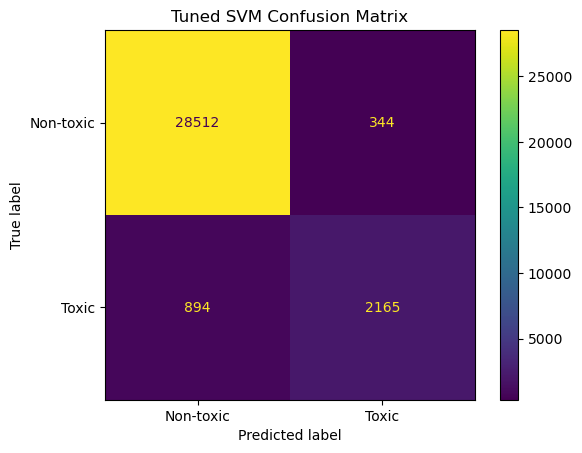

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_svm_tuned)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-toxic", "Toxic"]
)

disp.plot()
plt.title("Tuned SVM Confusion Matrix")
plt.show()


In [53]:
from sklearn.metrics import classification_report

# Detailed evaluation of the tuned Logistic Regression
print("Tuned Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_logreg_tuned))

Tuned Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28856
           1       0.89      0.64      0.75      3059

    accuracy                           0.96     31915
   macro avg       0.93      0.82      0.86     31915
weighted avg       0.96      0.96      0.96     31915



In [54]:
from sklearn.metrics import classification_report

# Detailed evaluation of the tuned Naive Bayes
print("Tuned Naive Bayes Classification Report")
print(classification_report(y_test, y_pred_nb_tuned))

Tuned Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     28856
           1       0.97      0.25      0.40      3059

    accuracy                           0.93     31915
   macro avg       0.95      0.63      0.68     31915
weighted avg       0.93      0.93      0.91     31915



# error analysis

# SVM

In [55]:
# Create a dataframe containing the test comments, actual labels, and predictions
error_df = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred_svm_tuned
})

# Keep only the incorrectly classified comments
errors = error_df[error_df["actual"] != error_df["predicted"]]

print("Total misclassified:", len(errors))

# Show 10 examples
print(errors.head(10))

Total misclassified: 1238
                                                     text  actual  predicted
26487   Don't you know silly rabbit that baseball play...       1          0
108158  Using your incredibly simple logic, Hopkins ca...       0          1
107444                          u mad bro? 186.86.130.176       0          1
123274  "\n\nHAHAHAHAHA.. I hate Slashdotters' jokes, ...       0          1
43693   HEY DJBULLSHIT, WORRY ABOUT YOUR OWN TALK PAGE...       1          0
78035   "\nAnd I say Doc James is a liar, he is clearl...       1          0
92750   The second member of his surname is not spelle...       1          0
71316   Go away, troll, I have been harassed and all I...       1          0
80631   Speculate? A retarded 10 year old child can se...       1          0
108161  Buenos dias, {{safesubst:BASEPAGENAME}}, and w...       1          0


In [56]:
# False negatives: actually toxic, but predicted as non-toxic
false_negatives = error_df[
    (error_df["actual"] == 1) & (error_df["predicted"] == 0)
]

# False positives: actually non-toxic, but predicted as toxic
false_positives = error_df[
    (error_df["actual"] == 0) & (error_df["predicted"] == 1)
]

print("FALSE NEGATIVES (Toxic → Non-toxic)")
print(false_negatives.head(5))

print("\nFALSE POSITIVES (Non-toxic → Toxic)")
print(false_positives.head(5))

FALSE NEGATIVES (Toxic → Non-toxic)
                                                    text  actual  predicted
26487  Don't you know silly rabbit that baseball play...       1          0
43693  HEY DJBULLSHIT, WORRY ABOUT YOUR OWN TALK PAGE...       1          0
78035  "\nAnd I say Doc James is a liar, he is clearl...       1          0
92750  The second member of his surname is not spelle...       1          0
71316  Go away, troll, I have been harassed and all I...       1          0

FALSE POSITIVES (Non-toxic → Toxic)
                                                     text  actual  predicted
108158  Using your incredibly simple logic, Hopkins ca...       0          1
107444                          u mad bro? 186.86.130.176       0          1
123274  "\n\nHAHAHAHAHA.. I hate Slashdotters' jokes, ...       0          1
119550  Why you have no life \n\nFlewis your deep invo...       0          1
117643  Oh, I can already spell a rfc coming Darkstar1...       0          1


# Save the trained model and vectorizer

In [57]:
import joblib

# Save the trained SVM model
joblib.dump(best_svm, "toxic_svm_model.pkl")

# Save the TF-IDF vectorizer used by the SVM
joblib.dump(tfidf_ngram, "toxic_tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
